### PSMNIST with Mamba

In [2]:
from __future__ import annotations
from typing import Dict, Any

import torch
import os
from pathlib import Path

from psmnist_task import PSMNISTTask
from src.train_utils.trainer import Trainer

### Configuration
We define a set of hyperparameters and configurations for the training process.
This includes data paths, batch sizes, learning rates, and model-specific parameters.
Using unified block factory from src.utils.block_factory for consistent configuration.

In [3]:
from src.utils.block_factory import make_mamba_block_cfg_ctor

In [5]:
current_dir = Path.cwd()
project_root = current_dir.parent.parent.parent
data_root = str(project_root / "src" / "datasets" / "psmnist" / "data")

args: Dict[str, Any] = {
    "data_root": data_root,
    "batch": 128,
    "data_loader_kwargs": {
        "num_workers": 0,
        "permutation_seed": 42,
        "normalize": "standard",
        "pin_memory": False,
        "persistent_workers": False,
    },

    "epochs": 50,
    "lr": 1e-3,
    "wd": 1e-4,
    "amp": False,
    "save_dir": "./runs/psmnist_mamba_task",
    "warmup_epochs": 5,
    "patience": 5,
    "min_delta": 0.001,
    "early_key": "accuracy",

    "d_model": 128,
    "depth": 2,
    "dropout": 0.1,
    "mlp_ratio": 2.0,
    "droppath_final": 0.0,
    "layerscale_init": 0.0,
    "residual_gain": 1.0,
    "pool": "mean",

    # Mamba-specific parameters
    "d_state": 16,
    "expand_factor": 2,
    "d_conv": 4,
    "use_external_mlp": False,
}

args["block_cfg_ctor"] = make_mamba_block_cfg_ctor(
    d_state=args["d_state"],
    expand_factor=args["expand_factor"],
    d_conv=args["d_conv"],
    use_external_mlp=args["use_external_mlp"],
    dropout=args["dropout"],
    mlp_ratio=args["mlp_ratio"],
    droppath_final=args["droppath_final"],
    layerscale_init=args["layerscale_init"],
    residual_gain=args["residual_gain"],
    pool=args["pool"],
)

if torch.cuda.is_available():
    args["device"] = torch.device("cuda")
    print(f"Using CUDA GPU: {torch.cuda.get_device_name(0)}")
elif torch.backends.mps.is_available():
    args["device"] = torch.device("mps")
    print("Using MPS (Apple Silicon)")
else:
    args["device"] = torch.device("cpu")
    args["amp"] = False
    print("Using CPU")

Using MPS (Apple Silicon)


### Training
With the configuration set up, we can now instantiate the `PSMNISTTask` and the `Trainer`.
The `fit` method on the trainer will start the training process, which includes training,
validation, and saving the best model based on the validation accuracy.

In [6]:
from src.utils.visualization import plot_classification_history as plot_history

In [ ]:
task = PSMNISTTask()

if torch.backends.mps.is_available() and args["device"].type == "mps":
    torch.mps.set_per_process_memory_fraction(0.9)

trainer = Trainer(args=args, task=task)

best_metric, ckpt_path = trainer.fit()
print(f"Done. Best {trainer.early_key}={best_metric:.4f} @ {ckpt_path}")

PS-MNIST Loaders Created:
  Train: 60000 samples, 468 batches
  Test:  10000 samples, 79 batches
  Permutation seed: 42
  Sequence length: 784 (28×28)
  Classes: 10 (digits 0-9)
Loaded checkpoint from epoch 3
Val metrics: {'loss': 0.554234764111042, 'time_s': 19.63263056613505, 'acc': 0.8249}


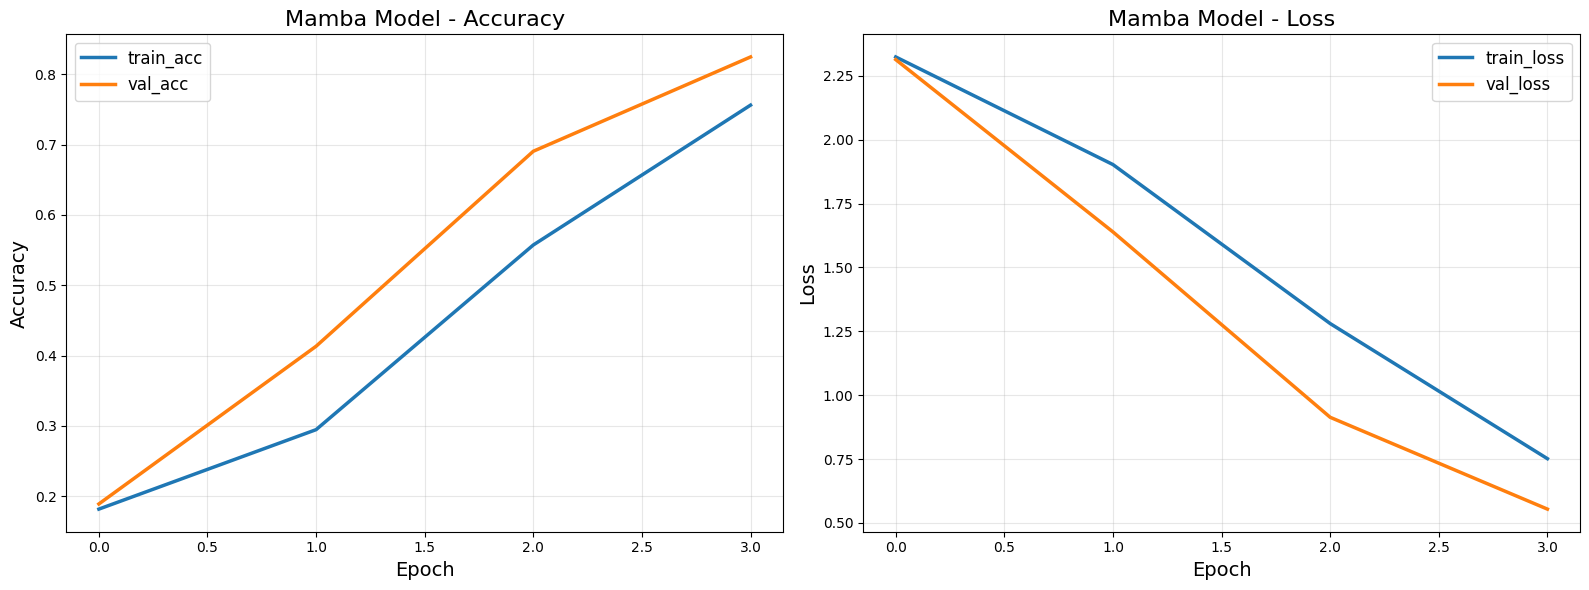

In [7]:
from src.utils.checkpoint import load_trainer_from_checkpoint

trainer = load_trainer_from_checkpoint(
    checkpoint_path=args["save_dir"] + "/best.pt",
    args=args,
    task=PSMNISTTask(),
)

history = trainer.history

plot_history(history, model_name="Mamba")

### Evaluation
After training, we can evaluate the best model on the test set.
We load the best model from the checkpoint and then run the evaluation.
The results, including accuracy, are printed.

PS-MNIST Loaders Created:
  Train: 60000 samples, 468 batches
  Test:  10000 samples, 79 batches
  Permutation seed: 42
  Sequence length: 784 (28×28)
  Classes: 10 (digits 0-9)
Loaded checkpoint from epoch 3
Val metrics: {'loss': 0.554234764111042, 'time_s': 19.63263056613505, 'acc': 0.8249}
PS-MNIST Loaders Created:
  Train: 60000 samples, 468 batches
  Test:  10000 samples, 79 batches
  Permutation seed: 42
  Sequence length: 784 (28×28)
  Classes: 10 (digits 0-9)

 Test results saved to: runs/psmnist_mamba_task/test_results.json

TEST SET RESULTS
   Accuracy: 0.8251 (82.51%)
   Loss: 0.5542
Overall accuracy: 0.8251
Num classes: 10

Top-10 and Bottom-10 Classes by Performance:
Top per-class accuracies:
01. class_1                   : 0.946
02. class_0                   : 0.897
03. class_8                   : 0.847
04. class_7                   : 0.846
05. class_4                   : 0.844
06. class_3                   : 0.835
07. class_6                   : 0.832
08. class_9        

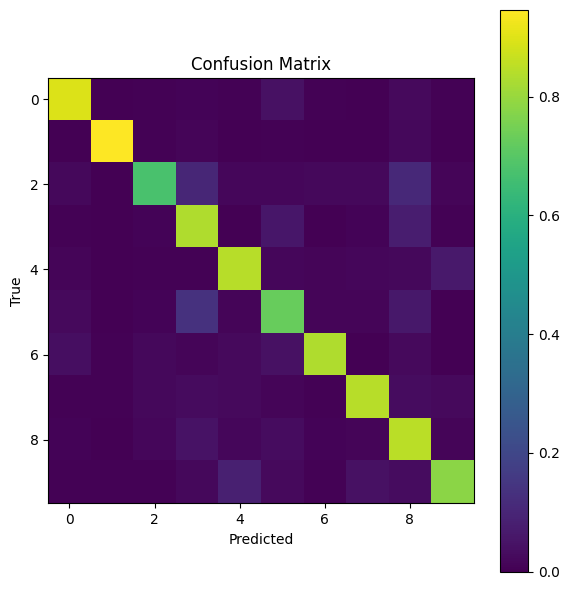

In [8]:
from src.eval.eval_utils import evaluate_classification_model as evaluate_best_model

logits_test, labels_test = evaluate_best_model(
    args=args,
    task=PSMNISTTask(),
    best_model_path=f"{args['save_dir']}/best.pt",
    num_classes=10,
    use_test_set=True,
)

### Changes in dataset length

In [ ]:
from src.eval.eval_utils import evaluate_classification_model as evaluate_best_model

if torch.backends.mps.is_available() and args["device"].type == "mps":
    torch.mps.set_per_process_memory_fraction(0.9)


for frac in [0.1, 0.25, 0.5]:
    print(f"\nTraining with fraction: {frac}")

    args["fraction"] = frac
    args["save_dir"] = f"./runs/psmnist_mamba_task_frac_{int(frac*100)}"
    trainer = Trainer(args=args, task=PSMNISTTask())
    best_metric, best_path = trainer.fit()

    print(f"\nTraining complete for fraction {frac}! Best validation {trainer.early_key}: {best_metric:.4f}")
    print(f"Best model saved to: {best_path}")

    history = trainer.history

    plot_history(history, model_name="Mamba")

    logits_test, labels_test = evaluate_best_model(
        args=args,
        task=PSMNISTTask(),
        best_model_path=best_path,
        num_classes=10,
        use_test_set=True,
    )